---
tags: [tutorial]
---

# 再利用パターン:QKernel、composite gate、opaque callable

Qamomileには3つの再利用パターンがあります。

ヘルパー`qkernel`は、通常のプログラム構造として使います。

`composite_gate()`は、Qamomileの本体を持つ名前付きの量子操作を作ります。

`opaque()`は、トップダウンのアルゴリズム設計とリソース推定に使う本体を持たないcallableを作ります。

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install qamomile

In [2]:
import qamomile.circuit as qmc
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

## パターン1:ヘルパーQKernel

通常のコード再利用をしたい場合は、ヘルパーqkernelを使います。

コンパイル時には、ヘルパー呼び出しは呼び出し元へインライン展開されます。

In [3]:
@qmc.qkernel
def entangle_once(q0: qmc.Qubit, q1: qmc.Qubit) -> tuple[qmc.Qubit, qmc.Qubit]:
    q0, q1 = qmc.cx(q0, q1)
    return q0, q1


@qmc.qkernel
def ghz_with_helper(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    q[0] = qmc.h(q[0])

    for i in qmc.range(n - 1):
        q[i], q[i + 1] = entangle_once(q[i], q[i + 1])

    return qmc.measure(q)

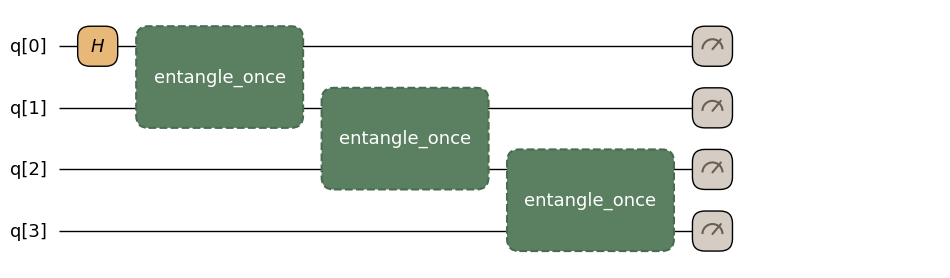

In [4]:
ghz_with_helper.draw(n=4, fold_loops=False)

In [5]:
result = (
    transpiler.transpile(ghz_with_helper, bindings={"n": 4})
    .sample(
        transpiler.executor(),
        shots=128,
    )
    .result()
)
print("GHZ result:", result.results)
assert result.shots == 128
assert sum(count for _, count in result.results) == 128
assert all(outcome in {(0, 0, 0, 0), (1, 1, 1, 1)} for outcome, _ in result.results)

GHZ result: [((0, 0, 0, 0), 62), ((1, 1, 1, 1), 66)]


### ヘルパーへのスカラーリテラルの受け渡し

ヘルパーqkernelでは、`UInt`、`Float`、`Bit`のようなスカラーハンドルを宣言できます。

呼び出し側では、生のPythonリテラルが期待されるハンドル型へ昇格されます。

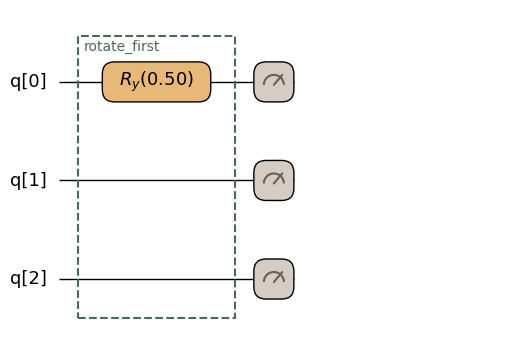

In [6]:
@qmc.qkernel
def rotate_first(
    q: qmc.Vector[qmc.Qubit],
    idx: qmc.UInt,
    angle: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    q[idx] = qmc.ry(q[idx], angle)
    return q


@qmc.qkernel
def helper_with_literals(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    q = rotate_first(q, 0, 0.5)  # type: ignore[arg-type]
    return qmc.measure(q)


helper_with_literals.draw(n=3, fold_loops=False, inline=True)

## パターン2:composite gate

再利用する単位を名前付きの量子操作として残したい場合は、composite gate callableを使います。

ユーザー向けの公開された書き方は、型付きPython関数に`@qmc.composite_gate`を付ける形です。

Qamomileはその関数を内部でqkernel本体に変換し、呼び出し側では名前付きboxとして残します。

In [ ]:
@qmc.composite_gate(
    name="h_layer",
    resource=qmc.ResourceMetadata(total_gates=3, single_qubit_gates=3),
)
def h_layer(q: qmc.Vector[qmc.Qubit]) -> qmc.Vector[qmc.Qubit]:
    for i in qmc.range(q.shape[0]):
        q[i] = qmc.h(q[i])
    return q


@qmc.qkernel
def custom_composite_layer() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(3, name="q")
    q = h_layer(q)
    return qmc.measure(q)


block = custom_composite_layer.build()
assert block.name == "custom_composite_layer"

composite_est = custom_composite_layer.estimate_resources().simplify()
assert composite_est.gates.total == 3

custom_composite_layer.draw(fold_loops=False)

QFTは組み込みの例です。

QFTはQamomileの本体を持ちますが、backendによってはnativeにemitできます。

['qft', 'iqft']


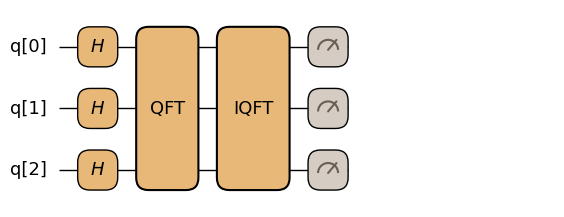

In [7]:
@qmc.qkernel
def qft_round_trip() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(3, name="q")
    q = qmc.h(q)
    q = qmc.qft(q)
    q = qmc.iqft(q)
    return qmc.measure(q)


block = qft_round_trip.build()
assert block.name == "qft_round_trip"

qft_est = qft_round_trip.estimate_resources().simplify()
print("QFT round-trip gates:", qft_est.gates.total)
assert qft_est.gates.total == 17

qft_round_trip.draw(fold_loops=False)

In [8]:
qft_result = (
    transpiler.transpile(qft_round_trip)
    .sample(
        transpiler.executor(),
        shots=64,
    )
    .result()
)
print("QFT round-trip result:", qft_result.results)
assert sum(count for _, count in qft_result.results) == 64

QFT round-trip result: [((0, 1, 1), 2), ((0, 0, 1), 6), ((1, 0, 0), 6), ((0, 0, 0), 6), ((0, 1, 0), 6), ((1, 1, 1), 12), ((1, 1, 0), 13), ((1, 0, 1), 13)]


## パターン3:opaque callable

実装がまだない段階で、アルゴリズムに名前付き操作が必要な場合はopaque callableを使います。

opaque callableは本体を持ちません。

それでもresource metadataを持てるため、リソース推定では呼び出しを数えられます。

In [9]:
marked_state_oracle = qmc.opaque(
    "marked_state_oracle",
    signature=qmc.CallableSignature(
        inputs=[qmc.Vector[qmc.Qubit]],
        outputs=[qmc.Vector[qmc.Qubit]],
    ),
    resource=qmc.ResourceMetadata(
        query_complexity=1,
        t_gates=40,
    ),
)


@qmc.qkernel
def grover_skeleton(rounds: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(3, name="q")
    q = qmc.h(q)

    for _ in qmc.range(rounds):
        q = marked_state_oracle(q)
        q = qmc.h(q)

    return q

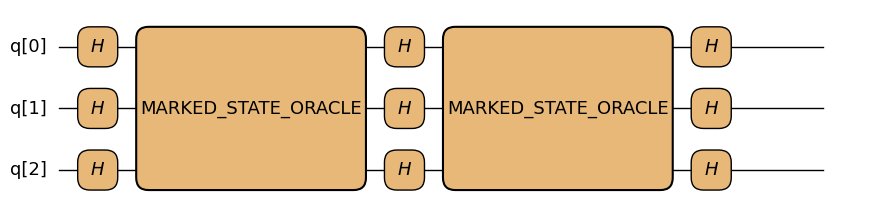

In [10]:
grover_skeleton.draw(rounds=2, fold_loops=False)

callableはopaqueなので、このqkernelはまだ実行できません。

それでもリソース推定には有用です。

In [11]:
est = grover_skeleton.estimate_resources().simplify()
print("qubits:", est.qubits)
print("total gates:", est.gates.total)
print("T gates:", est.gates.t_gates)
print("oracle calls:", est.gates.oracle_calls)
print("oracle queries:", est.gates.oracle_queries)
assert est.qubits == 3
assert str(est.gates.total) == "3*rounds + 3"
assert str(est.gates.t_gates) == "40*rounds"
assert {k: str(v) for k, v in est.gates.oracle_calls.items()} == {
    "marked_state_oracle": "rounds"
}
assert {k: str(v) for k, v in est.gates.oracle_queries.items()} == {
    "marked_state_oracle": "rounds"
}

qubits: 3
total gates: 3*rounds + 3
T gates: 40*rounds
oracle calls: {'marked_state_oracle': rounds}
oracle queries: {'marked_state_oracle': rounds}


具体的なループ回数を代入すると、数値的な見積もりを確認できます。

In [12]:
est_4 = est.substitute(rounds=4)
print("T gates for 4 rounds:", est_4.gates.t_gates)
assert est_4.gates.t_gates == 160
assert est_4.gates.oracle_calls == {"marked_state_oracle": 4}

T gates for 4 rounds: 160


## まとめ

通常のコード構造には、ヘルパー`qkernel`を使います。

呼び出しに本体があり、名前付き操作として可視化したい場合は`composite_gate()`を使います。

本体がまだない呼び出しを、図やリソース推定に含めたい場合は`opaque()`を使います。

制御ゲート(`qmc.control`)については、[チュートリアル04:制御ゲート](04_controlled_gates.ipynb)を参照してください。